In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargar la partición (Ya tienes instalada la librería)
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import NaturalIdPartitioner

fds = FederatedDataset(
    dataset="flwrlabs/femnist",
    partitioners={"train": NaturalIdPartitioner(partition_by="writer_id")}
)

# Cargamos la primera partición como ejemplo
partition = fds.load_partition(partition_id=0)

# 2. Función para visualizar una muestra
def visualizar_muestras(dataset, n_imagenes=10):
    plt.figure(figsize=(15, 3))
    
    for i in range(n_imagenes):
        # Extraer la imagen y la etiqueta
        item = dataset[i]
        imagen = item['image']
        etiqueta = item['label']
        
        # Convertir a array de numpy si es necesario
        img_array = np.array(imagen)
        
        plt.subplot(1, n_imagenes, i + 1)
        plt.imshow(img_array, cmap='gray')
        plt.title(f"Label: {etiqueta}")
        plt.axis('off')
    
    plt.show()

# Ejecutar visualización
visualizar_muestras(partition)

Generating partition_id_to_indices: 814277it [00:00, 1117374.04it/s]


KeyError: 'label'

<Figure size 1500x300 with 0 Axes>

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Inspeccionar las columnas disponibles
print(f"Columnas disponibles en el dataset: {partition.column_names}")

def visualizar_muestras(dataset, n_imagenes=10):
    # Detectar el nombre de la columna de etiquetas (suele ser 'character' en FEMNIST)
    col_etiqueta = 'character' if 'character' in dataset.column_names else dataset.column_names[1]
    
    plt.figure(figsize=(15, 3))
    
    for i in range(n_imagenes):
        item = dataset[i]
        imagen = item['image']
        etiqueta = item[col_etiqueta]
        
        img_array = np.array(imagen)
        
        plt.subplot(1, n_imagenes, i + 1)
        plt.imshow(img_array, cmap='gray')
        # El valor suele ser un índice, puedes mostrarlo directamente
        plt.title(f"ID: {etiqueta}")
        plt.axis('off')
    
    plt.show()

# Ejecutar visualización
visualizar_muestras(partition)

NameError: name 'partition' is not defined

In [4]:
partition.column_names

['image', 'writer_id', 'hsf_id', 'character']

In [6]:
import numpy as np

# 1. Convertir imágenes a vectores de 784 elementos (28x28)
# 2. Normalizar los píxeles a un rango de [0, 1]
X = np.array([np.array(img).flatten() for img in partition['image']]) / 255.0

# 3. Extraer las etiquetas reales solo para comparar después
y = np.array(partition['character'])

print(f"Ahora tienes una matriz X de {X.shape[0]} muestras y {X.shape[1]} características.")

Ahora tienes una matriz X de 382 muestras y 784 características.


In [7]:
import numpy as np
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42)

In [8]:
print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

Conjunto de entrenamiento: 286 muestras
Conjunto de prueba: 96 muestras


In [3]:
from datasets import load_dataset
import numpy as np

# 1. Cargar el dataset completo (solo el split de entrenamiento)
# Usamos 'streaming=False' para poder mezclar y seleccionar una porción
raw_dataset = load_dataset("flwrlabs/femnist", split="train")

# 2. Mezclar y seleccionar las primeras 20,000 instancias
# Esto asegura que tengas una mezcla de muchos autores y diferentes caracteres
dataset_subset = raw_dataset.shuffle(seed=42).select(range(20000))

print("Procesando imágenes...")

# 3. Crear la matriz X (Imágenes aplanadas y normalizadas)
# Cada imagen de 28x28 se convierte en un vector de 784
X = np.array([np.array(img).flatten() for img in dataset_subset['image']]) / 255.0

# 4. Crear el vector y (Etiquetas reales)
# En FEMNIST la columna de la clase suele llamarse 'character'
y = np.array(dataset_subset['character'])

print(f"¡Listo!")
print(f"Forma de X: {X.shape} (Instancias, Píxeles)")
print(f"Forma de y: {y.shape} (Etiquetas)")

Procesando imágenes...
¡Listo!
Forma de X: (20000, 784) (Instancias, Píxeles)
Forma de y: (20000,) (Etiquetas)


In [1]:
# PARA 20000 INSTANCIAS, 784 CARACTERÍSTICAS, 62 CLASES DIFERENTES
from datasets import load_dataset
import numpy as np

# 1. Cargar el dataset completo
raw_dataset = load_dataset("flwrlabs/femnist", split="train")

# 2. Seleccionar 200,000 muestras aleatorias
# Usamos un seed para que siempre obtengas las mismas si repites el código
dataset_subset = raw_dataset.shuffle(seed=42).select(range(200000))

print("Procesando 200k imágenes... esto puede tomar un momento.")

# 3. Conversión eficiente a NumPy
# Usamos float32 en lugar de float64 para ahorrar la MITAD de memoria RAM
X = np.array([np.array(img).flatten() for img in dataset_subset['image']], dtype=np.float32) / 255.0
y = np.array(dataset_subset['character'], dtype=np.int32)

print(f"Carga completa.")
print(f"Forma de X: {X.shape}") # (200000, 784)
print(f"Uso estimado de RAM para X: {(X.nbytes / 1024**2):.2f} MB")

Procesando 200k imágenes... esto puede tomar un momento.
Carga completa.
Forma de X: (200000, 784)
Uso estimado de RAM para X: 598.14 MB


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42)

In [26]:
from sklearn.cluster import KMeans

k = 62  # Número de clases en FEMNIST
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)

In [28]:
print(X_digits_dist.shape)
print(X_digits_dist)

(150000, 62)
[[4.218997  3.2851775 3.4739943 ... 3.1543639 4.5801377 3.963776 ]
 [4.280221  3.8017485 3.9172425 ... 4.2985277 4.7411256 4.018137 ]
 [3.8672915 3.3697777 3.6068764 ... 3.4222932 4.122597  4.3957357]
 ...
 [4.423329  2.9988515 2.4590924 ... 3.945632  4.4209733 4.468011 ]
 [4.3962197 3.6205087 3.0359752 ... 3.8232574 4.5014553 4.4934473]
 [5.121581  4.799542  4.6851463 ... 4.6862044 5.127236  4.6964116]]


In [29]:
idxs = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[idxs]

In [30]:
print(X_representative_digits.shape)
print(X_representative_digits)

(62, 784)
[[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]]


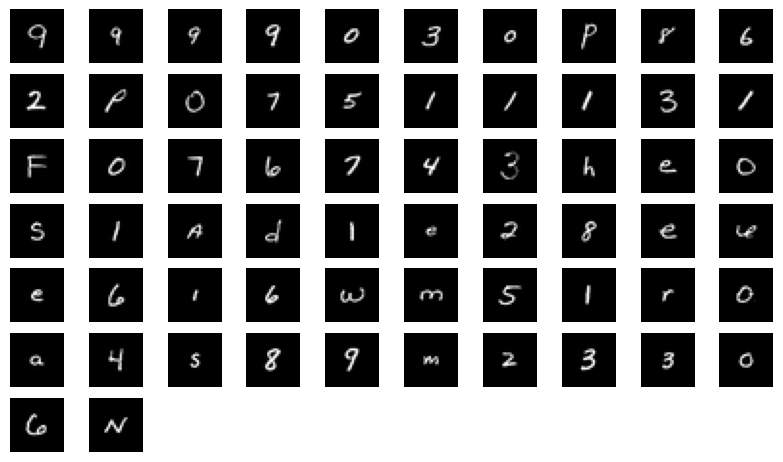

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 15))
for index, X_representative_digit in enumerate(X_representative_digits):
  plt.subplot(18, 10, index+1)
  plt.imshow(X_representative_digit.reshape(28,28), cmap="binary")
  plt.axis('off')
plt.show()

In [32]:
y_representative_digits = y_train[idxs]

In [33]:
from sklearn.linear_model import LogisticRegression


log_reg2 = LogisticRegression(solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg2.fit(X_representative_digits, y_representative_digits)
log_reg2.score(X_test, y_test)

CPU times: total: 1.09 s
Wall time: 849 ms


0.35198

In [35]:
log_reg = LogisticRegression(solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg.fit(X_train[:50], y_train[:50])
log_reg.score(X_test, y_test)

c:\Users\aaran\torch_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1201: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


CPU times: total: 1.08 s
Wall time: 905 ms


0.19672

In [36]:
y_train_propagated = np.empty(len(X_train))
for i in range(k):
  y_train_propagated[kmeans.labels_==i] = y_representative_digits[i]

In [38]:
log_reg3 = LogisticRegression(solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg3.fit(X_train[:1000], y_train_propagated[:1000])
log_reg3.score(X_test, y_test)

CPU times: total: 10.5 s
Wall time: 2.17 s


0.36684

In [39]:
probas = log_reg3.predict_proba(X_train[:1000])
labels_ixs = np.argmax(probas, axis=1)
labels = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])
sorted_ixs = np.argsort(labels)
labels[sorted_ixs[:10]]

array([0.17952335, 0.2208795 , 0.22246225, 0.22798667, 0.22852834,
       0.23080166, 0.24127923, 0.2485506 , 0.25528123, 0.26044264])

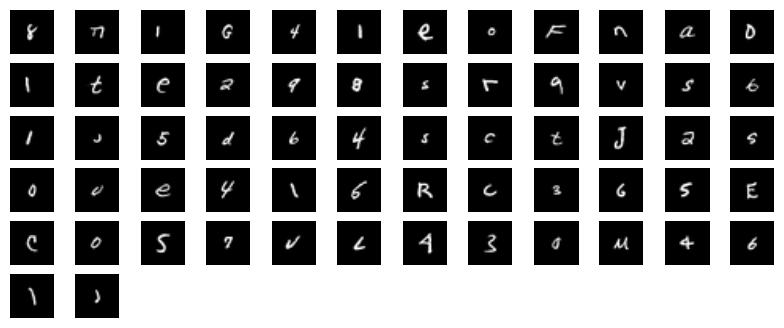

In [43]:
X_lowest = X_train[:1000][sorted_ixs[:k]]
plt.figure(figsize=(10, 4))
for index, img in enumerate(X_lowest):
    plt.subplot(k // 10, 12, index + 1)
    plt.imshow(img.reshape(28, 28), cmap="binary", interpolation="bilinear")
    plt.axis('off')
plt.show()

In [45]:
y_lowest = y_train[:1000][sorted_ixs[:k]]
y_lowest

array([ 8, 49,  1, 16,  4,  1, 40,  0, 15, 49, 36,  0, 47, 55, 40,  2, 42,
       42, 28, 53,  9, 31, 28,  6,  1, 19,  5, 39,  6,  4, 28, 12, 55, 19,
        2, 28, 24, 30, 40,  4, 47,  6, 27, 12,  3,  6,  5, 14, 38,  0,  5,
        7, 31, 21,  4,  3, 24, 22,  4,  6,  1, 19], dtype=int32)

In [46]:
y_train2 = y_train_propagated[:1000].copy()
y_train2[sorted_ixs[:k]] = y_lowest

In [ ]:
log_reg5 = LogisticRegression(solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg5.fit(X_train[:1000], y_train2)
log_reg5.score(X_test, y_test)

CPU times: total: 8.84 s
Wall time: 2.57 s


0.37776